# 5. Choosing the estimator and the architecture

Notebooks 01 to 04 used one estimator and one architecture by default. Those are arguments that can be changed and adapted to the estimation task you're running.

In this notebook we vary those choices and test them against known answers. Every option is listed with its parameters in `reference/PARAMETERS.md`.

## Imports

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import neural_mi as nmi
from neural_mi.models import BaseEmbedding
from neural_mi.generators import SharedLatentGaussian

## Cost knobs

In [2]:
# --- Cost knobs -----------------------------------------------------------
# Safe to reduce. These cost precision and leave the conclusions standing.

N_EPOCHS   = 120
PATIENCE   = 40
N_IID      = 4_000        # samples in the independent pair
T_TEMPORAL = 8_000       # timepoints in the autocorrelated pair
CRITIC_EVAL = 512         # section 3's evaluation group, kept small on purpose

# Load-bearing.

N_SEEDS = 3
# Every comparison here is between numbers a few percent apart. At one repeat
# there is no way to tell a difference from a draw.

MODELS = ['mlp', 'cnn', 'gru', 'tcn', 'transformer']
# Section 2 needs at least one model that cannot take a flat pair, to make
# the shape contract visible.

IID_MI  = 3.0      # exact MI of the independent pair
IID_MI_SWEEP = np.linspace(1.0, 10.0, 10) # section 1's MI sweep
WINDOW  = 5        # window for the temporal pair
SEED    = 0

N_WORKERS = 4
# How many runs go at once. Set it to your core count.

# Heavy: every cell below trains. A separable critic scores an evaluation group
# of K with one matrix product. The hybrid and concat critics put all K^2 pairs
# through a network. CRITIC_EVAL caps that group. Raising it slows section 3.

## The data

Here we use two paired datasets with exact answers. One has independent
samples (so there is no time dependence and we don't need windowing) and the other is an autocorrelated process (there is time dependence and we cut it into windows).

In [3]:
x_iid, y_iid = nmi.generators.generate_correlated_gaussians(
    n_samples=N_IID, dim=6, mi=IID_MI, seed=SEED)

oracle = SharedLatentGaussian(dims={'x': 4, 'y': 4}, d=2, phi=0.9,
                              coupling=0.4, noise=1.0, seed=SEED)
sample = oracle.sample(T=T_TEMPORAL, seed=SEED)
x_tmp, y_tmp = sample['x'], sample['y']
EXACT_TEMPORAL = float(oracle.block_mi(WINDOW))

WINDOWED = nmi.Processing(x='continuous', y='continuous',
                          x_params={'window_size': WINDOW, 'step_size': WINDOW},
                          y_params={'window_size': WINDOW, 'step_size': WINDOW})
REPEATS = dict(sweep_grid={'run_id': list(range(N_SEEDS))},
               n_workers=N_WORKERS, seed=SEED, show_progress=False)


def spread(result):
    # One configuration, so one row: the mean and spread over its repeats.
    row = result.dataframe.iloc[0]
    return float(row['mi_mean']), float(row['mi_std'])


print(f"independent pair : {x_iid.shape}, exact {IID_MI:.3f} bits")
print(f"temporal pair    : {x_tmp.shape}, windows of {WINDOW}, "
      f"exact {EXACT_TEMPORAL:.3f} bits")

independent pair : torch.Size([4000, 6]), exact 3.000 bits
temporal pair    : (8000, 4), windows of 5, exact 1.661 bits


## 1. InfoNCE and SMILE

An estimator is a critic function that learns embeddings and a loss function that scores them in a certain way to output MI as a number. Such estimators trade bias against variance (see notebook 02).

The default estimator is InfoNCE. Notebook 02 section 6 showed its ceiling of
$\log_2 K$ for an evaluation group of size $K$. Because InfoNCE is a high-bias,
low-variance estimator, repeated runs land close to each other and could still
be systematically far from the right answer. The strongest example of that bias
is the evaluation ceiling. No InfoNCE estimate can exceed the log of the
evaluation size, whatever the data holds. SMILE is another estimator the library
implements. Because it clips the density ratio instead of bounding it, its
answer is not capped the way InfoNCE's is. SMILE is less biased and has more
variance.

We show that in the sweep below as we try to estimate higher and higher MI
values. We cap the evaluation size at 32 samples so that InfoNCE can't estimate
more than $\log_2{32}=5$ bits. Note the warnings and variance of both
estimators.

In [4]:
t0 = time.time()
estimator_rows = []
for MI in IID_MI_SWEEP:
    row = {'MI': MI}
    # Generate a new dataset with the requested MI.
    x_iid_sweep, y_iid_sweep = nmi.generators.generate_correlated_gaussians(
    n_samples=N_IID, dim=6, mi=MI, seed=SEED)

    for name in ('infonce', 'smile'):
        r = nmi.run(x_iid_sweep, y_iid_sweep, mode='sweep',
                    model=nmi.Model(embedding_dim=32, hidden_dim=128),
                    training=nmi.Training(n_epochs=N_EPOCHS, batch_size=256,
                                          patience=PATIENCE, max_eval_samples=32),
                    estimator=nmi.Estimator(name),
                    split=nmi.Split(mode='random'), **REPEATS)
        row[name], row[name + '_sd'] = spread(r)
        row['ceiling'] = float(r.runs['train_ceiling_mi'].mean())
    estimator_rows.append(row)
    print(f"MI {row['MI']:>5}  ceiling {row['ceiling']:>5.2f}  "
          f"infonce {row['infonce']:.3f}+/-{row['infonce_sd']:.3f}  "
          f"smile {row['smile']:.3f}+/-{row['smile_sd']:.3f}", flush=True)
print(f"({time.time() - t0:.0f}s)")

MI   1.0  ceiling  5.00  infonce 1.056+/-0.112  smile 1.071+/-0.124


MI   2.0  ceiling  5.00  infonce 1.894+/-0.100  smile 1.997+/-0.163


MI   3.0  ceiling  5.00  infonce 2.625+/-0.088  smile 2.881+/-0.187


MI   4.0  ceiling  5.00  infonce 3.382+/-0.083  smile 3.811+/-0.357


MI   5.0  ceiling  5.00  infonce 3.761+/-0.127  smile 4.683+/-0.219


...

MI  10.0  ceiling  5.00  infonce 4.883+/-0.051  smile 7.970+/-0.391


2026-09-30 18:04:58 - neural_mi - WARNING - 'Peak-epoch selection may be unreliable: 86% of the smoothed test-MI history sits above 90%...' was raised 24 times in this cell and shown once.


2026-09-30 18:04:58 - neural_mi - WARNING - 'InfoNCE estimate is near its ceiling: test MI (4.446 bits) vs' was raised 12 times in this cell and shown once.


2026-09-30 18:04:58 - neural_mi - WARNING - 'Training completed all 120 epoch(s) without early stopping and the best (smoothed) test MI...' was raised 4 times in this cell and shown once.


(269s)


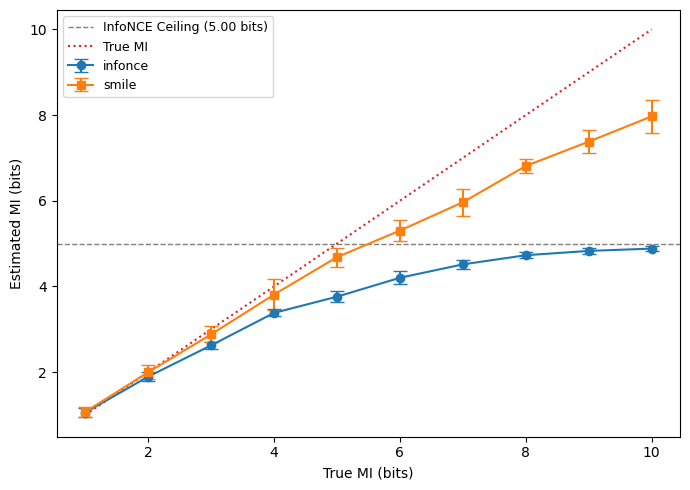

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.axhline(estimator_rows[0]['ceiling'], color='tab:gray', ls='--', lw=1, zorder=0, label=r'InfoNCE Ceiling'+f' ({estimator_rows[0]["ceiling"]:.2f} bits)')
ax.plot(IID_MI_SWEEP, IID_MI_SWEEP, ':', color='tab:red',
        label=r'True MI', zorder=0)
for name, marker in (('infonce', 'o'), ('smile', 's')):
    ax.errorbar(IID_MI_SWEEP, [r[name] for r in estimator_rows],
                yerr=[r[name + '_sd'] for r in estimator_rows],
                fmt=marker + '-', capsize=5, label=name)
ax.set_xlabel('True MI (bits)')
ax.set_ylabel('Estimated MI (bits)')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

Both estimators behave as advertised and neither is perfect.

InfoNCE has a strong bias that pulls it down as it approaches $\log_2{32}=5$
bits and a very small variance across individual runs.

SMILE is less biased and tracks the true MI better. It still deviates at large
MI values and carries more variance across individual runs.

InfoNCE is a good default because in many cases we want a precise number with
clear error bars even when the value is systematically biased. We can also raise
the ceiling at some computational cost by evaluating on larger chunks of our
data. SMILE is what you try if you can't increase the evaluation size and the
ceiling is in the way. Reading the ceiling next to the estimate tells you which
case you are in. The library warns when an estimate is near it.

## 2. The embedding model

Each input passes through an embedding network before the critic scores it. The
embedding network maps the input into the low-dimensional embedding space. The
better its inductive bias matches the data (a CNN for an image, for example),
the easier it is for the network to discover the relations between your
datasets. You can choose from several embedding models using
`Model(embedding_model=...)`.

**Note:** The options differ in what
input shape they accept.

In [6]:
t0 = time.time()
TRAIN = nmi.Training(n_epochs=N_EPOCHS, batch_size=256, patience=PATIENCE)
model_rows = []
for name in MODELS:
    spec = nmi.Model(embedding_model=name, embedding_dim=32, hidden_dim=128)
    try:
        iid_mean, iid_sd = spread(nmi.run(x_iid, y_iid, mode='sweep', model=spec,
                                          training=TRAIN,
                                          split=nmi.Split(mode='random'), **REPEATS))
    except ValueError:
        # Sequence models need a time axis and say so instead of guessing.
        iid_mean = iid_sd = None
    tmp_mean, tmp_sd = spread(nmi.run(x_tmp, y_tmp, mode='sweep', model=spec,
                                      training=TRAIN, processing=WINDOWED, **REPEATS))
    model_rows.append(dict(name=name, iid=iid_mean, iid_sd=iid_sd,
                           tmp=tmp_mean, tmp_sd=tmp_sd))
    shown = ('   needs a time axis' if iid_mean is None
             else f"{iid_mean:>9.3f}+/-{iid_sd:<5.3f}")
    print(f"{name:>12} {shown} {tmp_mean:>9.3f}+/-{tmp_sd:<5.3f}", flush=True)
print(f"({time.time() - t0:.0f}s)")

         mlp     3.090+/-0.035     1.667+/-0.172


         cnn     3.093+/-0.083     1.440+/-0.152


         gru    needs a time axis     1.635+/-0.031


         tcn     3.081+/-0.083     1.726+/-0.089


 transformer     3.064+/-0.091     1.497+/-0.008


(148s)


A model has to be able to accept the shape you hand it. A flat pair of samples
has no time axis. If you ask a recurrent model to read one, it raises an error.

Among the models that do run, the answers land close to each other and to the
truth (3.0 bits for the first column, 1.66 bits for the second one). Because the relationships here, static or temporal, are relatively easy to learn, the data sets the accuracy more than the architecture does.

## 3. The critic

The critic turns embeddings into a score. `separable` takes their dot
product, `concat` puts every pair through a network, and `hybrid` sits between
them.

- Because separable scores the two embeddings by their dot product, the relation
  between them has to be linear in the embedding space. That usually takes more
  embedding dimensions than the data's true dimensionality. When only the MI
  value matters, a relatively large embedding (the default is 64) works. It is
  cheap to run and the library's default in every mode except
  `mode='dimensionality'`. There the extra dimensions matter and the hybrid
  critic is used instead.
- Concat assumes no form for the interaction. It puts every possible pair
  through one network. For an evaluation size $K$ that is $K^2$ inputs to the
  network where separable embeds $K$ samples and takes one matrix product.
  Concat also leaves no clean way to obtain the embeddings. It is the most
  general critic and the one you are least likely to need.
- Hybrid sits between the two. Like separable, it has two separate networks and
  two sets of embeddings. It scores them with a small network on top of their
  concatenation that can learn an arbitrary relation between them. It runs
  about as fast as separable and faster than concat, stays general, and does
  not inflate the number of embedding dimensions needed. The library uses it by
  default only in `mode='dimensionality'` because those properties matter
  there.

In [7]:
t0 = time.time()
critic_rows = []
for critic in ('separable', 'hybrid', 'concat'):
    t1 = time.time()
    mean, sd = spread(nmi.run(x_iid, y_iid, mode='sweep',
                              model=nmi.Model(critic_type=critic, embedding_dim=32,
                                              hidden_dim=128),
                              training=nmi.Training(n_epochs=N_EPOCHS, batch_size=256,
                                                    patience=PATIENCE,
                                                    max_eval_samples=CRITIC_EVAL),
                              split=nmi.Split(mode='random'),
                              **REPEATS))
    critic_rows.append(dict(name=critic, mean=mean, sd=sd, seconds=time.time() - t1))
    print(f"{critic:>12} {mean:>9.3f}+/-{sd:<5.3f}  "
          f"{time.time() - t1:>6.0f}s", flush=True)
print(f"({time.time() - t0:.0f}s)")

   separable     3.058+/-0.037      16s


      hybrid     2.937+/-0.067      23s


      concat     2.982+/-0.063      61s


ipykernel_78134/4153228184.py:5: UserWarning: Training completed all 120 epoch(s) without early stopping and the best (smoothed) test MI occurred at the final epoch. MI may still have been rising when training stopped. The reported estimate may then be an under-trained lower bound. Raise n_epochs or lower patience to let early stopping act.
  mean, sd = spread(nmi.run(x_iid, y_iid, mode='sweep',
2026-09-30 18:09:05 - neural_mi - WARNING - 'Training completed all 120 epoch(s) without early stopping and the best (smoothed) test MI...' was raised 3 times in this cell and shown once.


(100s)


All three critics arrive within a few percent of the correct value. Separable
is the default because it gets there at the lowest cost.

## 4. Your own embedding

A fully connected mlp is a universal approximator. Given enough samples it can
learn any mapping from the observed modality to the embedding. It is the
library's default and the baseline to compare a changed architecture against.

Usually, what an architecture buys is sample efficiency. A convolution applied
to an image starts from the assumption that nearby pixels are related and spends
no data discovering that. The same idea applies to a population recording whose
channels are not a streamlined rectangular block. Neurons arrive in groups whose
internal order is an accident of the probe. A model that learns a separate
function per channel spends samples on that accident.

The library accepts a class through `custom_embedding_cls` for exactly this. It
is constructed as `YourClass(input_dim, hidden_dim=..., embedding_dim=...,
n_layers=...)` with the same names you write in `Model(...)`. `input_style`
decides what `input_dim` means: `'flattened'` (the default) hands you
`n_channels * window_size` and `'channels'` hands you the channel count and
leaves the window axis to you. In both cases `forward` still receives the full
`(batch, channels, window)` tensor.

Because one class serves both sides of the critic unless you say otherwise, a
class written around X's channel count will be built for Y as well.
`embedding_model_y` and `custom_embedding_cls_y` give Y its own.

**Note:** This section runs with `n_workers=1` because a class defined in a
notebook cannot be pickled to spawned worker processes. Moving the class into an
importable module removes that restriction.

### A population where the structure is real

The recording holds two groups of neurons. A latent drives the first group up
and the second group down. The behavioural variable follows that same latent.
The signal is therefore the *contrast* between the groups that summing over
every channel cancels.

That makes these claims about the data testable against one another:

- pooling within a group and keeping the groups apart is right,
- pooling over everything is wrong and throws the signal away,
- assuming nothing, as the mlp does, is always available and always defensible.

In [8]:
# --- The population -------------------------------------------------------
GROUP_CH = 64          # channels per group, so 2 * GROUP_CH in total
CH_NOISE = 3.0         # per-channel noise that pooling averages away
N_GRID   = [100, 200, 400, 800, 1600]   # training-set sizes to compare at


def population(n_samples, seed):
    """Group A rides +z, group B rides -z, and y follows z."""
    rng = np.random.default_rng(seed)
    z = rng.standard_normal((n_samples, 1))
    x = np.hstack([+z + CH_NOISE * rng.standard_normal((n_samples, GROUP_CH)),
                   -z + CH_NOISE * rng.standard_normal((n_samples, GROUP_CH))])
    y = z + rng.standard_normal((n_samples, 1))
    return x.astype(np.float32), y.astype(np.float32)


# The exact answer comes from the generating covariance instead of from a
# sample, so the target does not drift as the sample size changes.
_d = 2 * GROUP_CH
_sign = np.r_[np.ones(GROUP_CH), -np.ones(GROUP_CH)]
_S = np.zeros((_d + 1, _d + 1))
_S[:_d, :_d] = np.outer(_sign, _sign) + (CH_NOISE ** 2) * np.eye(_d)
_S[:_d, _d] = _sign
_S[_d, :_d] = _sign
_S[_d, _d] = 2.0
POP_MI = float(0.5 * np.log(np.linalg.det(_S[:_d, :_d]) * _S[_d, _d]
                            / np.linalg.det(_S)) / np.log(2))

_x_demo, _ = population(4_000, SEED)
_z_demo = _x_demo[:, :GROUP_CH].mean(1) - _x_demo[:, GROUP_CH:].mean(1)
print(f"{2 * GROUP_CH} channels, exact MI {POP_MI:.3f} bits")
print(f"  correlation of the group contrast with the total sum: "
      f"{np.corrcoef(_z_demo, _x_demo.sum(1))[0, 1]:+.3f}")

128 channels, exact MI 0.454 bits
  correlation of the group contrast with the total sum: -0.020


In [9]:
class PooledOverAll(BaseEmbedding):
    """One shared encoder per channel, summed over every channel.

    Permutation invariant across the whole population. That is the wrong
    assumption here, because the sum it computes is the quantity the two groups cancel.
    """

    input_style = 'channels'

    def __init__(self, input_dim, hidden_dim=64, embedding_dim=32, n_layers=2, **kwargs):
        super().__init__()
        self.phi = nn.Sequential(nn.Linear(1, hidden_dim), nn.ReLU(),
                                 nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
        self.rho = nn.Linear(hidden_dim, embedding_dim)

    def forward(self, x):                      # x: (batch, channels, window)
        batch, channels, _ = x.shape
        per = self.phi(x.mean(-1).reshape(batch * channels, 1)).reshape(batch, channels, -1)
        return self.rho(per.sum(1))


class PooledByGroup(BaseEmbedding):
    """The same shared encoder, pooled inside each group, groups kept apart.

    Permutation invariant *within* a group and not across them, matching the
    structure the probe has. The parameter count does not depend on how
    many channels each group holds.
    """

    input_style = 'channels'
    n_groups = 2

    def __init__(self, input_dim, hidden_dim=64, embedding_dim=32, n_layers=2, **kwargs):
        super().__init__()
        size = input_dim // self.n_groups
        self.splits = [slice(i * size, input_dim if i == self.n_groups - 1 else (i + 1) * size)
                       for i in range(self.n_groups)]
        self.phi = nn.Sequential(nn.Linear(1, hidden_dim), nn.ReLU(),
                                 nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
        self.rho = nn.Linear(hidden_dim * self.n_groups, embedding_dim)

    def forward(self, x):
        batch, channels, _ = x.shape
        per = self.phi(x.mean(-1).reshape(batch * channels, 1)).reshape(batch, channels, -1)
        return self.rho(torch.cat([per[:, s].sum(1) for s in self.splits], dim=-1))


# Y is one behavioural channel, so it gets an mlp of its own. Without
# embedding_model_y it would be built from the X-side class, and that class is
# written around a channel count Y does not have.
ARMS = {
    'mlp': nmi.Model(embedding_model='mlp', embedding_dim=32, hidden_dim=128, n_layers=2),
    'pooled over all': nmi.Model(custom_embedding_cls=PooledOverAll, embedding_model_y='mlp',
                                 embedding_dim=32, hidden_dim=128, n_layers=2),
    'pooled by group': nmi.Model(custom_embedding_cls=PooledByGroup, embedding_model_y='mlp',
                                 embedding_dim=32, hidden_dim=128, n_layers=2),
}

In [10]:
# Heavy: len(N_GRID) * 3 arms * N_SEEDS training runs, one at a time because a
# notebook-defined class cannot cross a process boundary.
t0 = time.time()
curve = {name: {'mean': [], 'std': []} for name in ARMS}
for n_samples in N_GRID:
    for name, model in ARMS.items():
        vals = []
        for seed in range(N_SEEDS):
            x_pop, y_pop = population(n_samples, seed)
            vals.append(float(nmi.run(
                x_pop, y_pop, mode='estimate', model=model,
                training=nmi.Training(n_epochs=N_EPOCHS, patience=PATIENCE,
                                      batch_size=min(256, max(32, n_samples // 4))),
                split=nmi.Split(mode='random'),
                seed=seed, n_workers=1, show_progress=False).mi_estimate))
        curve[name]['mean'].append(float(np.mean(vals)))
        curve[name]['std'].append(float(np.std(vals, ddof=1)))

print(f"exact {POP_MI:.3f} bits" + f"   ({time.time() - t0:.0f}s)")
print(f"{'N':>6}" + "".join(f"{name:>24}" for name in ARMS))
for i, n_samples in enumerate(N_GRID):
    cells = "".join(f"{curve[k]['mean'][i]:>13.3f} +-{curve[k]['std'][i]:<8.3f}" for k in ARMS)
    print(f"{n_samples:>6}{cells}")

ipykernel_78134/2084951864.py:10: UserWarning: Only 100 samples reach the estimator. The samples an estimate needs grow roughly as N ~ d^2/I (tutorial 02, section 2). Here d is the number of latent dimensions carrying the shared information and I is the information itself. Neither is known before estimating. A few latent dimensions carrying several bits can settle within a few hundred samples. Many dimensions or little information need far more. mode='rigorous' tests whether the estimate still moves with the sample size. At this size regularisation also helps: dropout=0.2; norm_layer='layer'; hidden_dim=32 (current: 128); optimizer='adamw' with optimizer_params={'weight_decay': 1e-3}.
  vals.append(float(nmi.run(


ipykernel_78134/2084951864.py:10: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0138 bits at epoch 0). The model learned no representation that generalises. This usually means too few epochs, too high a learning rate or degenerate data. Train MI is reported as 0 bits. The raw train MI was 0.0636 bits and most likely reflects overfitting. Raise n_epochs, lower learning_rate or inspect the data.
  vals.append(float(nmi.run(


ipykernel_78134/2084951864.py:10: UserWarning: Training completed all 120 epoch(s) without early stopping and the best (smoothed) test MI occurred at the final epoch. MI may still have been rising when training stopped. The reported estimate may then be an under-trained lower bound. Raise n_epochs or lower patience to let early stopping act.
  vals.append(float(nmi.run(


2026-09-30 18:11:26 - neural_mi - WARNING - 'Only 100 samples reach the estimator' was raised 9 times in this cell and shown once.


2026-09-30 18:11:26 - neural_mi - WARNING - 'All test MI values in the training history are non-positive (max test MI = -0.0138 bits at...' was raised 4 times in this cell and shown once.


2026-09-30 18:11:26 - neural_mi - WARNING - 'Training completed all 120 epoch(s) without early stopping and the best (smoothed) test MI...' was raised 3 times in this cell and shown once.


exact 0.454 bits   (140s)
     N                     mlp         pooled over all         pooled by group
   100        0.897 +-0.778           0.070 +-0.061           0.478 +-0.069   
   200        0.639 +-0.282           0.066 +-0.062           0.449 +-0.049   
   400        0.664 +-0.260           0.110 +-0.031           0.443 +-0.067   
   800        0.484 +-0.014           0.059 +-0.052           0.436 +-0.017   
  1600        0.505 +-0.050           0.080 +-0.012           0.443 +-0.015   


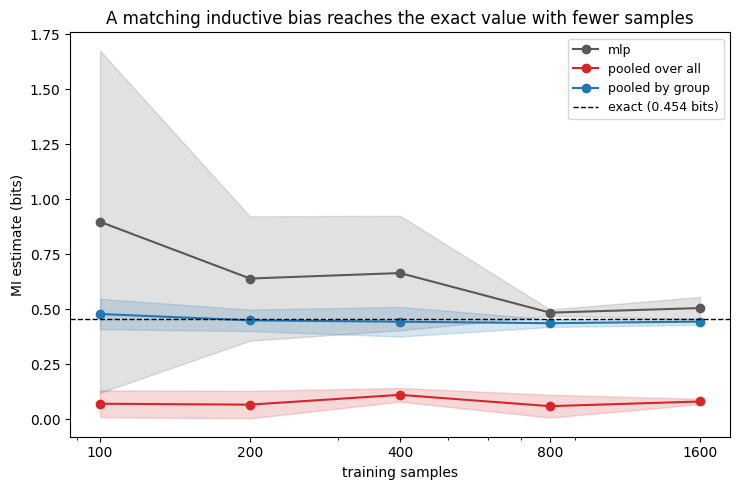

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 5))
colours = {'mlp': '0.35', 'pooled over all': 'tab:red', 'pooled by group': 'tab:blue'}
for name in ARMS:
    m, s = np.array(curve[name]['mean']), np.array(curve[name]['std'])
    ax.plot(N_GRID, m, 'o-', color=colours[name], label=name)
    ax.fill_between(N_GRID, m - s, m + s, color=colours[name], alpha=0.18)
ax.axhline(POP_MI, color='k', ls='--', lw=1, label=f'exact ({POP_MI:.3f} bits)')
ax.set_xscale('log')
ax.set_xticks(N_GRID)
ax.set_xticklabels(N_GRID)
ax.set_xlabel('training samples')
ax.set_ylabel('MI estimate (bits)')
ax.set_title('A matching inductive bias reaches the exact value with fewer samples')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The mlp arrives at the right answer eventually and converges toward the exact
value from above as the samples accumulate. It has to spend samples first to
learn that there are two groups and then to find the right relationship between
them. This is why in general the mlp is a good default when you have nothing to
assume.

The grouped encoder doesn't need to spend those samples. It *knows* a priori
that it should learn structure within the two groups and gets there almost
immediately with a much tighter spread. When we have a good inductive bias about
the data, an architecture that matches it, or a pretrained model as a starting
point, saves samples. You can supply your own architecture or a pretrained
backbone; see `pretrained_backbone` in `reference/USING.md` for details.

The wrong bias gets you nowhere. Pooling over every channel effectively destroys the relationship you're looking for. In this case, no amount of extra data will repair that.

**Summary:** Using an encoder that's matched to the data you're trying to
estimate on gets you to the accurate estimate faster and in principle can teach
you something about how the data is organised (e.g., you can investigate the
filters of a CNN). On the other hand, an encoder that's not matched to the data
hurts you by costing more samples to learn something you already know or by
destroying what you're looking for in the first place.


**Note:** A critic can be supplied the same way through `custom_critic`. Both
sides of the critic can take their own encoder through the `_y` settings used
above. See `reference/USING.md` for details.

## Where this goes next

This notebook ends the series. Notebooks 01 to 05 covered why mutual information
needs a neural estimator, what a single estimate is and how to check it, which
quantity a question asks for, how to turn a recording into tensors, and when to
change the estimator or the architecture. That is enough to estimate information
on your own recordings.

The library does more than the series showed. `reference/USING.md` has the call
for every task, including the modes the notebooks left out: temporal lags,
spike-timing precision, all-to-all channel matrices, directions of shared
structure and permutation tests. `reference/PARAMETERS.md` lists every setting
with its default, `reference/THEORY.md` explains what each reported quantity
means, and `reference/MESSAGES.md` explains every warning the library prints.

Before you report a number from your own data, go through the protocol at the end
of notebook 02: the quantity and its units, a check against a known value, a
control, and the spread.